# 🏛️ Analisis Daya Beli: Panel Data Econometrics & Machine Learning

## Pendekatan Multi-Skenario untuk Prediksi Daya Beli Per Kapita

### Perubahan dari Notebook Lama:
- ❌ **One-Hot Encoding Provinsi** mendominasi feature importance → ✅ **Fixed Effects** menangkap variasi antar-provinsi tanpa mendistorsi koefisien makro
- ❌ **Ridge Regression** tidak melakukan feature selection → ✅ **Lasso + XGBoost** untuk feature selection dan non-linear
- ❌ **Feature importance tidak interpretable** → ✅ **PanelOLS t-statistics + Tree-based gain importance**
- ❌ **Tidak ada skenario kebijakan** → ✅ **Counterfactual / What-If Analysis**

### Skenario:
1. **Baseline OLS**: Model interpretatif tanpa fixed effects
2. **Panel FE Macro**: Fixed effects + variabel ekonomi makro (MODEL UTAMA)
3. **Panel FE Full**: Fixed effects + semua fitur (IPM, GDP, demografi)
4. **Lasso**: Feature selection otomatis (L1 regularization)
5. **Random Forest & XGBoost**: Non-linear relationships & gain-based importance

### Output:
- Feature importance yang bermakna untuk kebijakan ekonomi
- Elastisitas daya beli per variabel
- Simulasi counterfactual (inflasi, UMP, resesi)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV

from linearmodels.panel import PanelOLS
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Helper function
def print_metrics(y_true, y_pred, label=''):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{label} R2: {r2:.4f} | MAE: Rp {mae:,.0f} | RMSE: Rp {rmse:,.0f}")
    return {'R2': r2, 'MAE': mae, 'RMSE': rmse}

print("Library loaded successfully")


Library loaded successfully


## 1. Load Data & EDA

In [2]:
# Load clean dataset
df = pd.read_csv('../datasets/processed/clean_daya_beli.csv')
print(f"Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")
print(f"Tahun: {df['Tahun'].min()}-{df['Tahun'].max()}, Provinsi: {df['Provinsi'].nunique()}")
print("Kolom:", df.columns.tolist())
df.head()


Dataset: 177 baris x 19 kolom
Tahun: 2021-2025, Provinsi: 38
Kolom: ['Provinsi', 'Tahun', 'Pengeluaran_Makanan', 'Pengeluaran_Bukan_Makanan', 'Total_Pengeluaran', 'UMP', 'TPT', 'TPAK', 'PDRB_HargaBerlaku', 'PDRB_HargaKonstan', 'Pct_Penduduk_Miskin', 'Inflasi_Rata_Tahunan', 'IPM', 'Jumlah_Penduduk', 'Pct_Populasi', 'Inflasi_WB_Annual', 'GDP_PerCapita_PPP', 'Pct_Unemployment_WB', 'Poverty_Headcount_Pct']


,Provinsi,Tahun,Pengeluaran_Makanan,Pengeluaran_Bukan_Makanan,Total_Pengeluaran,UMP,TPT,TPAK,PDRB_HargaBerlaku,PDRB_HargaKonstan,Pct_Penduduk_Miskin,Inflasi_Rata_Tahunan,IPM,Jumlah_Penduduk,Pct_Populasi,Inflasi_WB_Annual,GDP_PerCapita_PPP,Pct_Unemployment_WB,Poverty_Headcount_Pct
0,Aceh,2021,643591.40,494227.92,1137819.32,3165031.0,6.300,64.460,34673.56,25356.45,15.33,0.155,72.18,5274.9,1.96,1.560079,12757.074644,3.827,10.1
1,Bali,2021,628472.06,840152.05,1468624.11,2494000.0,5.395,73.625,50758.32,33123.79,4.53,0.155,75.69,4317.4,1.60,1.560079,12757.074644,3.827,10.1
2,Banten,2021,744893.26,766363.40,1511256.67,2460997.0,8.995,64.035,55383.29,38339.42,6.66,0.155,72.72,11904.6,4.42,1.560079,12757.074644,3.827,10.1
3,Bengkulu,2021,580273.31,558299.08,1138572.40,2215000.0,3.685,70.745,39167.13,23545.64,15.22,0.155,71.64,2010.7,0.75,1.560079,12757.074644,3.827,10.1
4,DI Yogyakarta,2021,594622.24,823248.11,1417870.35,1765000.0,4.420,73.165,40516.00,29115.86,12.80,0.155,80.22,3668.7,1.36,1.560079,12757.074644,3.827,10.1


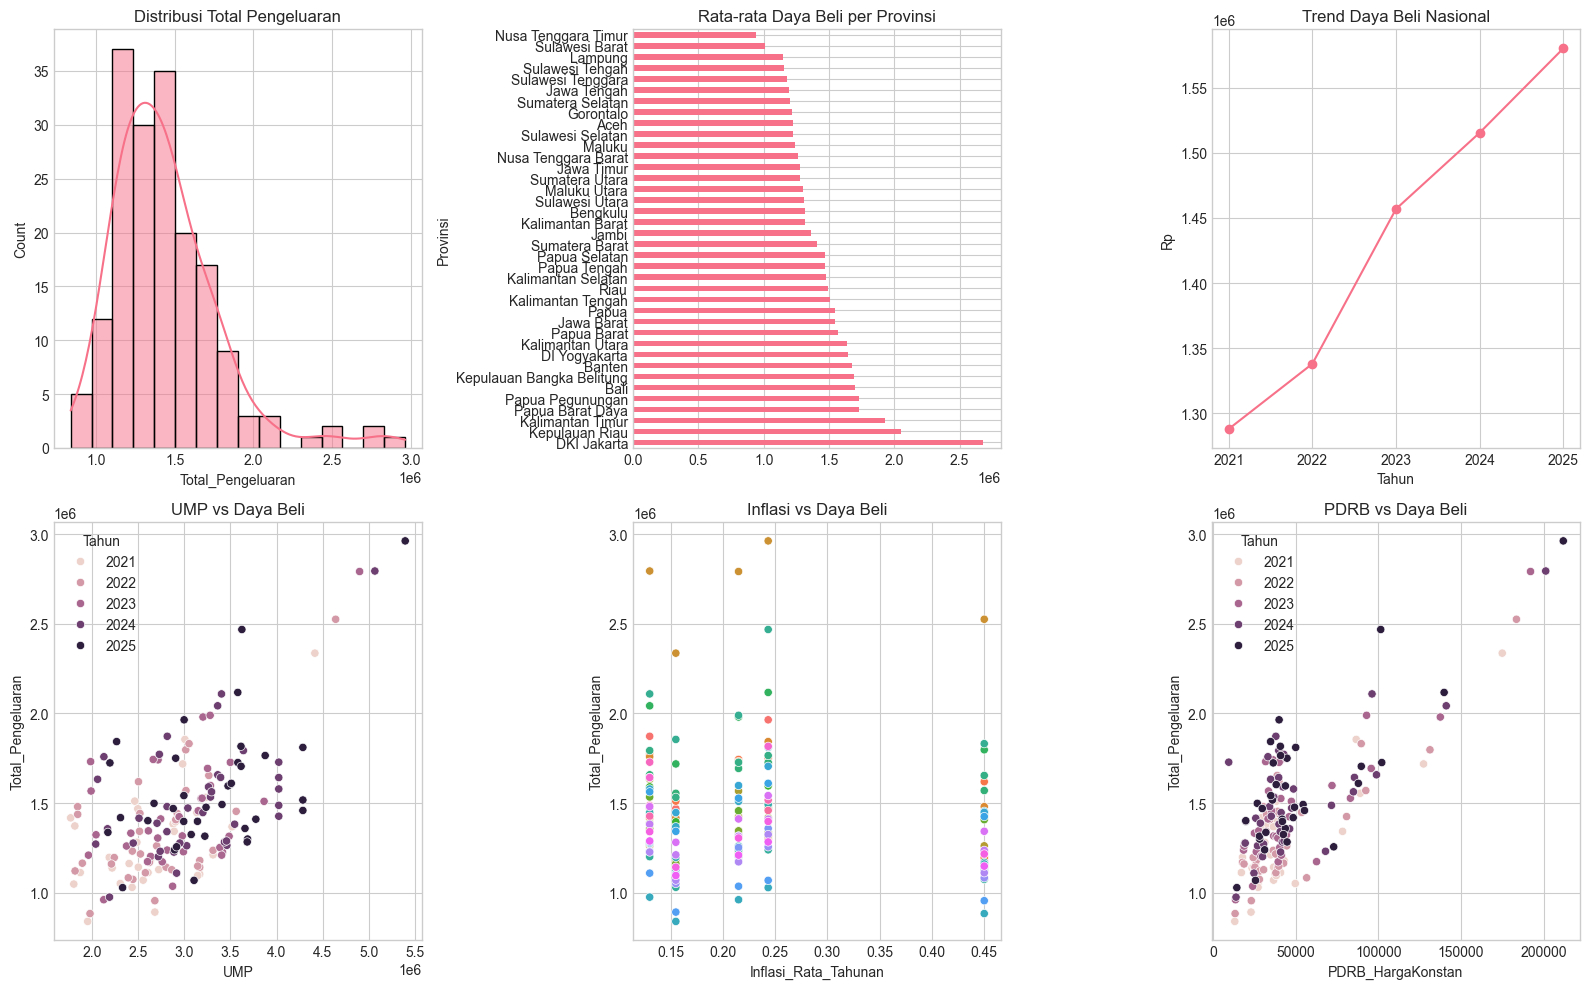

Insight:
   - Daya beli tertinggi: DKI Jakarta (Rp 2,682,078)
   - Daya beli terendah: Nusa Tenggara Timur (Rp 938,112)
   - Rasio tertinggi/terendah: 2.9x


In [3]:
# Quick EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Target distribution
sns.histplot(df['Total_Pengeluaran'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Distribusi Total Pengeluaran')

# Daya beli per provinsi (rata-rata)
prov_mean = df.groupby('Provinsi')['Total_Pengeluaran'].mean().sort_values(ascending=False)
prov_mean.plot(kind='barh', ax=axes[0,1])
axes[0,1].set_title('Rata-rata Daya Beli per Provinsi')

# Trend tahunan
trend = df.groupby('Tahun')['Total_Pengeluaran'].mean()
trend.plot(marker='o', ax=axes[0,2])
axes[0,2].set_title('Trend Daya Beli Nasional')
axes[0,2].set_ylabel('Rp')

# UMP vs Pengeluaran
sns.scatterplot(data=df, x='UMP', y='Total_Pengeluaran', hue='Tahun', ax=axes[1,0])
axes[1,0].set_title('UMP vs Daya Beli')

# Inflasi vs Pengeluaran
sns.scatterplot(data=df, x='Inflasi_Rata_Tahunan', y='Total_Pengeluaran', hue='Provinsi', 
                legend=False, ax=axes[1,1])
axes[1,1].set_title('Inflasi vs Daya Beli')

# PDRB vs Pengeluaran
sns.scatterplot(data=df, x='PDRB_HargaKonstan', y='Total_Pengeluaran', hue='Tahun', ax=axes[1,2])
axes[1,2].set_title('PDRB vs Daya Beli')

plt.tight_layout()
plt.show()

print("Insight:")
print(f"   - Daya beli tertinggi: {prov_mean.index[0]} (Rp {prov_mean.iloc[0]:,.0f})")
print(f"   - Daya beli terendah: {prov_mean.index[-1]} (Rp {prov_mean.iloc[-1]:,.0f})")
print(f"   - Rasio tertinggi/terendah: {prov_mean.iloc[0]/prov_mean.iloc[-1]:.1f}x")


## 2. Feature Engineering

Fitur baru yang dibuat:
- **Real_UMP** = UMP / (1 + Inflasi) → daya beli upah riil
- **YoY Growth** → pertumbuhan tahunan per provinsi
- **Interaction terms** → UMP x PDRB, Inflasi x TPT
- **Log transforms** → untuk distribusi skewed


In [4]:
print("Feature Engineering...")

# 1. Real UMP (purchasing power)
df['Real_UMP'] = df['UMP'] / (1 + df['Inflasi_Rata_Tahunan'])
print("   Real_UMP = UMP / (1 + Inflasi)")

# 2. Sort for time-series operations
df = df.sort_values(['Provinsi', 'Tahun']).reset_index(drop=True)

# 3. YoY Growth rates (within province)
growth_features = ['Total_Pengeluaran', 'Real_UMP', 'PDRB_HargaKonstan', 'TPT']
for col in growth_features:
    df[f'{col}_Growth'] = df.groupby('Provinsi')[col].pct_change() * 100
    print(f"   {col}_Growth (YoY %)")

# 4. Interaction terms (economic hypotheses)
df['UMP_x_PDRB'] = df['Real_UMP'] * df['PDRB_HargaKonstan']
df['Inflasi_x_TPT'] = df['Inflasi_Rata_Tahunan'] * df['TPT']
print("   Interaction: UMP x PDRB, Inflasi x TPT")

# 5. Log transforms for skewed variables
df['Log_Total_Pengeluaran'] = np.log1p(df['Total_Pengeluaran'])
df['Log_PDRB'] = np.log1p(df['PDRB_HargaKonstan'])
df['Log_UMP'] = np.log1p(df['Real_UMP'])
print("   Log transforms")

# 6. Impute missing values in provincial/WB features
wb_cols = [c for c in df.columns if 'WB' in c or 'GDP' in c or 'Poverty' in c or 'Unemployment' in c]
prov_cols = ['IPM', 'Jumlah_Penduduk', 'Pct_Populasi']
for cols in [wb_cols, prov_cols]:
    if cols and df[cols].isna().sum().sum() > 0:
        before = df[cols].isna().sum().sum()
        df[cols] = df.groupby('Provinsi')[cols].transform(lambda x: x.ffill().bfill())
        after = df[cols].isna().sum().sum()
        print(f"   [IMPUTASI] {before-after} NaN diisi di {cols}")

# Drop irrelevant columns
drop_cols = ['UMP', 'PDRB_HargaBerlaku', 'TPAK', 'Pct_Penduduk_Miskin',
             'Pengeluaran_Makanan', 'Pengeluaran_Bukan_Makanan']
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Drop rows with NaN in critical columns
critical_cols = ['Total_Pengeluaran', 'Real_UMP', 'PDRB_HargaKonstan', 'TPT', 'Inflasi_Rata_Tahunan']
df_model = df_model.dropna(subset=critical_cols).copy()

print(f"Dataset siap: {df_model.shape[0]} baris x {df_model.shape[1]} kolom")
print(f"   NaN tersisa: {df_model.isna().sum().sum()}")

df_model.head()


Feature Engineering...
   Real_UMP = UMP / (1 + Inflasi)
   Total_Pengeluaran_Growth (YoY %)
   Real_UMP_Growth (YoY %)
   PDRB_HargaKonstan_Growth (YoY %)
   TPT_Growth (YoY %)
   Interaction: UMP x PDRB, Inflasi x TPT
   Log transforms
   [IMPUTASI] 0 NaN diisi di ['IPM', 'Jumlah_Penduduk', 'Pct_Populasi']
Dataset siap: 177 baris x 23 kolom
   NaN tersisa: 159


,Provinsi,Tahun,Total_Pengeluaran,TPT,PDRB_HargaKonstan,Inflasi_Rata_Tahunan,IPM,Jumlah_Penduduk,Pct_Populasi,Inflasi_WB_Annual,...,Real_UMP,Total_Pengeluaran_Growth,Real_UMP_Growth,PDRB_HargaKonstan_Growth,TPT_Growth,UMP_x_PDRB,Inflasi_x_TPT,Log_Total_Pengeluaran,Log_PDRB,Log_UMP
0,Aceh,2021,1137819.32,6.300,25356.45,0.155000,72.18,5274.9,1.96,1.560079,...,2.740287e+06,NaN,NaN,NaN,NaN,6.948394e+10,0.976500,13.944625,10.140828,14.823573
1,Aceh,2022,1180132.93,6.070,26061.53,0.450000,72.80,5334.9,1.96,4.209465,...,2.183766e+06,3.718834,-20.308864,2.780673,-3.650794,5.691227e+10,2.731500,13.981138,10.168254,14.596562
2,Aceh,2023,1225976.00,5.890,26800.14,0.215000,73.40,5409.2,1.97,3.669387,...,2.809602e+06,3.884568,28.658577,2.834101,-2.965404,7.529772e+10,1.266350,14.019249,10.196200,14.848554
3,Aceh,2024,1264733.00,5.655,27684.18,0.130000,74.03,5554.8,1.97,2.181513,...,3.062542e+06,3.161318,9.002698,3.298639,-3.989813,8.478395e+10,0.735150,14.050372,10.228653,14.934756
4,Aceh,2025,1299756.00,5.570,28144.60,0.243333,74.03,5554.8,1.98,2.181513,...,2.964302e+06,2.769201,-3.207766,1.663116,-1.503095,8.342911e+10,1.355367,14.077688,10.245146,14.902153


## 3. Train-Test Split (Chronological)

In [5]:
# Chronological split: Train <=2023, Test >=2024
train = df_model[df_model['Tahun'] <= 2023].copy()
test = df_model[df_model['Tahun'] >= 2024].copy()
train_panel = train.set_index(['Provinsi', 'Tahun'])
test_panel = test.set_index(['Provinsi', 'Tahun'])

print(f"Train: {len(train)} ({train['Tahun'].min()}-{train['Tahun'].max()})")
print(f"Test:  {len(test)} ({test['Tahun'].min()}-{test['Tahun'].max()})")

y_train = train['Total_Pengeluaran'].values
y_test = test['Total_Pengeluaran'].values


Train: 102 (2021-2023)
Test:  75 (2024-2025)


## 4. Skenario 1: Baseline OLS (Interpretatif)

Model tanpa fixed effects. Tujuan: melihat pengaruh murni Inflasi dan UMP.


In [6]:
print("="*60)
print("SKENARIO 1: BASELINE OLS")
print("="*60)

features_s1 = ['Tahun', 'Inflasi_Rata_Tahunan', 'Real_UMP']
X_train_s1 = sm.add_constant(train[features_s1])
X_test_s1 = sm.add_constant(test[features_s1])

model_s1 = sm.OLS(y_train, X_train_s1).fit()
print(model_s1.summary())

# VIF
vif_data = pd.DataFrame()
vif_data['Feature'] = features_s1
vif_data['VIF'] = [variance_inflation_factor(X_train_s1[features_s1].values, i) for i in range(len(features_s1))]
print("VIF:", vif_data.to_string(index=False))

# Metrics
pred_s1_train = model_s1.predict(X_train_s1)
pred_s1_test = model_s1.predict(X_test_s1)
print_metrics(y_train, pred_s1_train, "Train")
print_metrics(y_test, pred_s1_test, "Test")


SKENARIO 1: BASELINE OLS
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.351
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     17.70
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           2.94e-09
Time:                        15:36:37   Log-Likelihood:                -1414.6
No. Observations:                 102   AIC:                             2837.
Df Residuals:                      98   BIC:                             2848.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const  

{'R2': 0.1827552493491743,
 'MAE': 256949.42178302174,
 'RMSE': np.float64(311074.26742630213)}

## 5. Skenario 2: Fixed Effects PanelOLS (MODEL UTAMA)

**Entity Fixed Effects** menangkap variasi antar-provinsi (level daya beli Jakarta vs Papua) tanpa membuat dummy variables yang mendistorsi feature importance.

Koefisien yang diestimasi = efek dalam-provinsi (within effect): bagaimana perubahan inflasi/UMP/PDRB/TPT di suatu provinsi mempengaruhi daya beli di provinsi tersebut.


In [7]:
print("="*60)
print("SKENARIO 2: FIXED EFFECTS PANELOLS (MODEL UTAMA)")
print("="*60)

fe_features = ['Inflasi_Rata_Tahunan', 'Real_UMP', 'PDRB_HargaKonstan', 'TPT']

# linearmodels PanelOLS (for beautiful econometric summary)
model_fe = PanelOLS(train_panel['Total_Pengeluaran'], train_panel[fe_features], entity_effects=True)
res_fe = model_fe.fit(cov_type='clustered', cluster_entity=True)
print(res_fe)

# Manual Fixed Effects (for sklearn-compatible prediction)
entity_means = {}
for col in ['Total_Pengeluaran'] + fe_features:
    entity_means[col] = train.groupby('Provinsi')[col].mean().to_dict()

train_demeaned = train.copy()
for col in ['Total_Pengeluaran'] + fe_features:
    train_demeaned[col] = train.apply(lambda r: r[col] - entity_means[col].get(r['Provinsi'], 0), axis=1)

model_fe_manual = sm.OLS(train_demeaned['Total_Pengeluaran'], train_demeaned[fe_features]).fit()

# Predict on test (add back entity means from training)
test_demeaned = test.copy()
for col in fe_features:
    test_demeaned[col] = test.apply(lambda r: r[col] - entity_means[col].get(r['Provinsi'], 0), axis=1)

pred_fe_test_dem = model_fe_manual.predict(test_demeaned[fe_features])
pred_fe_test = pred_fe_test_dem + test['Provinsi'].apply(lambda p: entity_means['Total_Pengeluaran'].get(p, 0))

pred_fe_train_dem = model_fe_manual.predict(train_demeaned[fe_features])
pred_fe_train = pred_fe_train_dem + train['Provinsi'].apply(lambda p: entity_means['Total_Pengeluaran'].get(p, 0))

print_metrics(y_train, pred_fe_train, "Train")
print_metrics(y_test, pred_fe_test, "Test")

# FE Feature Importance (t-statistics)
fe_importance = pd.DataFrame({
    'Feature': fe_features,
    'Coefficient': model_fe_manual.params.values,
    't_stat': np.abs(model_fe_manual.tvalues.values),
    'p_value': model_fe_manual.pvalues.values
}).sort_values('t_stat', ascending=False)

print("FE Feature Importance (|t-stat|):")
for _, row in fe_importance.iterrows():
    sig = "***" if row['p_value'] < 0.01 else "**" if row['p_value'] < 0.05 else "*" if row['p_value'] < 0.1 else ""
    print(f"   {row['Feature']}: coef={row['Coefficient']:+.2f}, |t|={row['t_stat']:.2f}, p={row['p_value']:.3f} {sig}")


SKENARIO 2: FIXED EFFECTS PANELOLS (MODEL UTAMA)
                          PanelOLS Estimation Summary                           
Dep. Variable:      Total_Pengeluaran   R-squared:                        0.7823
Estimator:                   PanelOLS   R-squared (Between):              0.6160
No. Observations:                 102   R-squared (Within):               0.7823
Date:                Fri, Jun 05 2026   R-squared (Overall):              0.6165
Time:                        15:36:37   Log-likelihood                   -1217.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      57.493
Entities:                          34   P-value                           0.0000
Avg Obs:                       3.0000   Distribution:                    F(4,64)
Min Obs:                       3.0000                                           
Max Obs:                       3.0000   F-statistic (robust)

## 6. Skenario 3: Full Model PanelOLS

Semua fitur non-derived (IPM, demografi, GDP, interaksi, log). Data leakage dihindari dengan men-drop `Total_Pengeluaran_Growth` dan `Log_Total_Pengeluaran`.


In [8]:
print("="*60)
print("SKENARIO 3: FULL MODEL PANELOLS")
print("="*60)

# Exclude target-derived features to prevent data leakage
exclude_derived = ['Total_Pengeluaran_Growth', 'Log_Total_Pengeluaran']
all_numeric = [c for c in df_model.columns 
               if c not in ['Provinsi', 'Tahun', 'Total_Pengeluaran', 'Log_Total_Pengeluaran'] + exclude_derived
               and df_model[c].dtype in ['float64', 'int64']]
all_numeric = [c for c in all_numeric if df_model[c].isna().sum() < 50]
print(f"Features ({len(all_numeric)}): {all_numeric}")

# Drop rows with NaN
train_full = train.dropna(subset=['Total_Pengeluaran'] + all_numeric).copy()
test_full = test.dropna(subset=['Total_Pengeluaran'] + all_numeric).copy()
print(f"Rows after NaN drop - Train: {len(train_full)}, Test: {len(test_full)}")

y_train_full = train_full['Total_Pengeluaran'].values
y_test_full = test_full['Total_Pengeluaran'].values

entity_means_full = {}
for col in ['Total_Pengeluaran'] + all_numeric:
    entity_means_full[col] = train_full.groupby('Provinsi')[col].mean().to_dict()

train_dem_full = train_full.copy()
for col in ['Total_Pengeluaran'] + all_numeric:
    train_dem_full[col] = train_full.apply(lambda r: r[col] - entity_means_full[col].get(r['Provinsi'], 0), axis=1)

model_fe_full_manual = sm.OLS(train_dem_full['Total_Pengeluaran'], train_dem_full[all_numeric]).fit()

test_dem_full = test_full.copy()
for col in all_numeric:
    test_dem_full[col] = test_full.apply(lambda r: r[col] - entity_means_full[col].get(r['Provinsi'], 0), axis=1)

pred_s3_test_dem = model_fe_full_manual.predict(test_dem_full[all_numeric])
pred_s3_test = pred_s3_test_dem + test_full['Provinsi'].apply(lambda p: entity_means_full['Total_Pengeluaran'].get(p, 0))
pred_s3_train_dem = model_fe_full_manual.predict(train_dem_full[all_numeric])
pred_s3_train = pred_s3_train_dem + train_full['Provinsi'].apply(lambda p: entity_means_full['Total_Pengeluaran'].get(p, 0))

print_metrics(y_train_full, pred_s3_train, "Train")
print_metrics(y_test_full, pred_s3_test, "Test")

fe_full_imp = pd.DataFrame({
    'Feature': all_numeric,
    'Coef': model_fe_full_manual.params.values,
    't_stat': np.abs(model_fe_full_manual.tvalues.values),
    'p_value': model_fe_full_manual.pvalues.values
}).sort_values('t_stat', ascending=False)
print("Top 10 FE Full:")
print(fe_full_imp.head(10)[['Feature', 'Coef', 't_stat', 'p_value']].to_string(index=False))


SKENARIO 3: FULL MODEL PANELOLS
Features (18): ['TPT', 'PDRB_HargaKonstan', 'Inflasi_Rata_Tahunan', 'IPM', 'Jumlah_Penduduk', 'Pct_Populasi', 'Inflasi_WB_Annual', 'GDP_PerCapita_PPP', 'Pct_Unemployment_WB', 'Poverty_Headcount_Pct', 'Real_UMP', 'Real_UMP_Growth', 'PDRB_HargaKonstan_Growth', 'TPT_Growth', 'UMP_x_PDRB', 'Inflasi_x_TPT', 'Log_PDRB', 'Log_UMP']
Rows after NaN drop - Train: 68, Test: 68


Train R2: 0.9983 | MAE: Rp 10,384 | RMSE: Rp 13,298
Test R2: -21.0335 | MAE: Rp 1,674,847 | RMSE: Rp 1,682,683
Top 10 FE Full:
              Feature          Coef   t_stat  p_value
Poverty_Headcount_Pct -3.028542e-01 4.534742 0.000032
    Inflasi_WB_Annual -1.635649e+00 4.534742 0.000032
    GDP_PerCapita_PPP  1.682989e+03 4.534742 0.000032
  Pct_Unemployment_WB -4.663954e-01 4.534742 0.000032
 Inflasi_Rata_Tahunan -7.115999e-01 4.533042 0.000033
                  TPT -1.145904e+05 4.211658 0.000097
      Real_UMP_Growth -2.639094e+04 3.281042 0.001816
              Log_UMP  2.342264e+06 2.410279 0.019376
        Inflasi_x_TPT  4.064105e+04 2.322841 0.023985
             Real_UMP -2.490405e-01 2.316497 0.024355


## 7. Skenario 4: Lasso Feature Selection

L1 regularization otomatis memilih fitur penting dan membuat koefisien tidak penting = 0.


In [9]:
print("="*60)
print("SKENARIO 4: LASSO FEATURE SELECTION")
print("="*60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_full[all_numeric])
X_test_scaled = scaler.transform(test_full[all_numeric])

alphas = np.logspace(-3, 2, 30)
lasso_cv = GridSearchCV(Lasso(max_iter=20000, random_state=42), {'alpha': alphas}, 
                        cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train_scaled, y_train_full)
print(f"Best alpha: {lasso_cv.best_params_['alpha']:.4f}")

lasso = Lasso(alpha=lasso_cv.best_params_['alpha'], max_iter=20000, random_state=42)
lasso.fit(X_train_scaled, y_train_full)

pred_lasso_train = lasso.predict(X_train_scaled)
pred_lasso_test = lasso.predict(X_test_scaled)
print_metrics(y_train_full, pred_lasso_train, "Train")
print_metrics(y_test_full, pred_lasso_test, "Test")

lasso_imp = pd.DataFrame({'Feature': all_numeric, 'Coefficient': lasso.coef_})
lasso_selected = lasso_imp[lasso_imp['Coefficient'] != 0].copy()
lasso_selected['abs_coef'] = np.abs(lasso_selected['Coefficient'])
lasso_selected = lasso_selected.sort_values('abs_coef', ascending=False)

print(f"Selected: {len(lasso_selected)}/{len(all_numeric)} features")
print(lasso_selected[['Feature', 'Coefficient']].to_string(index=False))


SKENARIO 4: LASSO FEATURE SELECTION


Best alpha: 100.0000
Train R2: 0.8483 | MAE: Rp 102,337 | RMSE: Rp 126,837
Test R2: 0.6793 | MAE: Rp 154,513 | RMSE: Rp 203,010
Selected: 15/18 features
                 Feature   Coefficient
              UMP_x_PDRB  2.858440e+05
            Pct_Populasi -1.754271e+05
       PDRB_HargaKonstan -1.509619e+05
         Jumlah_Penduduk  1.310763e+05
                Log_PDRB  9.169616e+04
                     IPM  8.674824e+04
    Inflasi_Rata_Tahunan -6.545315e+04
                     TPT  5.624757e+04
                Real_UMP -4.556202e+04
              TPT_Growth -3.317012e+04
           Inflasi_x_TPT  2.451975e+04
PDRB_HargaKonstan_Growth  5.776454e+03
       Inflasi_WB_Annual -4.215097e+02
       GDP_PerCapita_PPP  7.875154e-11
     Pct_Unemployment_WB -1.112794e-11


## 8. Skenario 5: Random Forest & XGBoost

Model non-linear untuk menangkap hubungan kompleks antar variabel. Feature importance berbasis **gain** (reduksi MSE).


SKENARIO 5: RANDOM FOREST & XGBOOST


RF Train R2: 0.8594 | MAE: Rp 81,013 | RMSE: Rp 122,120
RF Test R2: 0.6934 | MAE: Rp 142,937 | RMSE: Rp 198,501


XGB Train R2: 1.0000 | MAE: Rp 143 | RMSE: Rp 186
XGB Test R2: 0.8342 | MAE: Rp 119,224 | RMSE: Rp 145,973


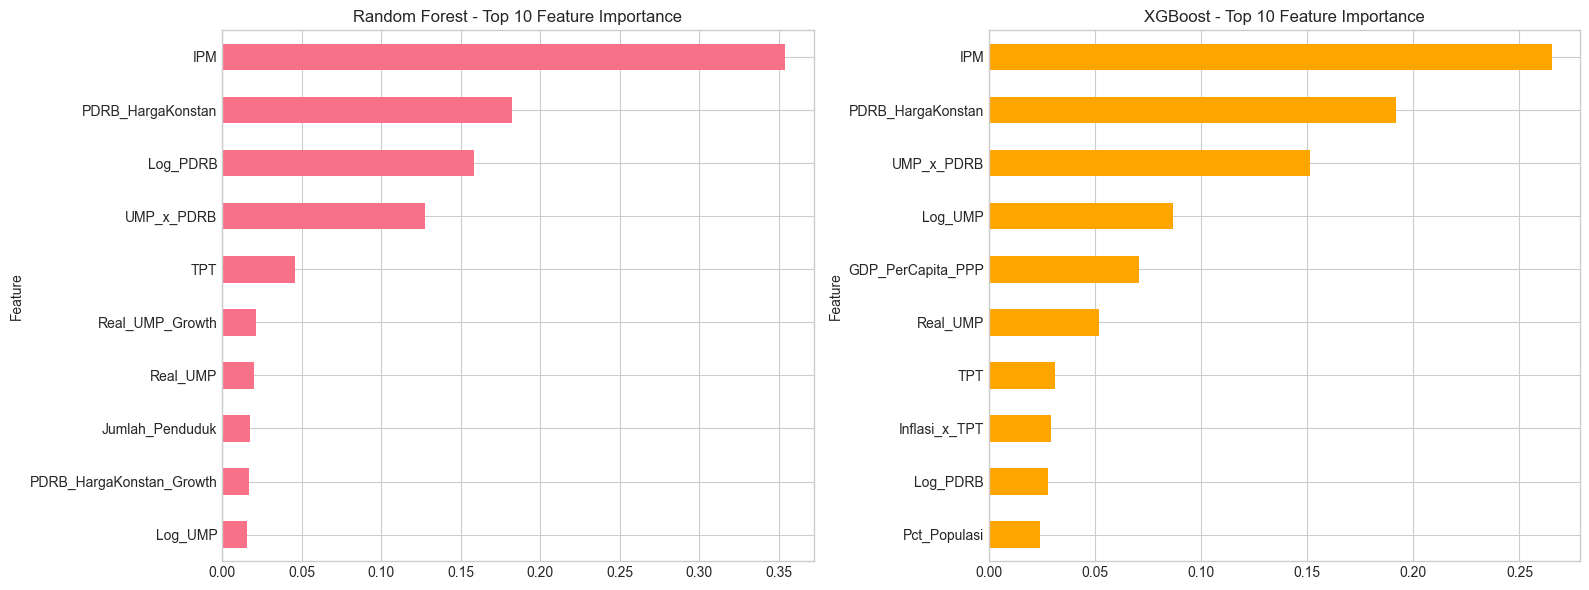

In [10]:
print("="*60)
print("SKENARIO 5: RANDOM FOREST & XGBOOST")
print("="*60)

# Random Forest
rf = RandomForestRegressor(n_estimators=500, max_depth=8, min_samples_split=5,
                             min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(train_full[all_numeric], y_train_full)
pred_rf_train = rf.predict(train_full[all_numeric])
pred_rf_test = rf.predict(test_full[all_numeric])
print_metrics(y_train_full, pred_rf_train, "RF Train")
print_metrics(y_test_full, pred_rf_test, "RF Test")

# XGBoost
xgb = XGBRegressor(n_estimators=500, max_depth=4, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb.fit(train_full[all_numeric], y_train_full, eval_set=[(test_full[all_numeric], y_test_full)], verbose=False)
pred_xgb_train = xgb.predict(train_full[all_numeric])
pred_xgb_test = xgb.predict(test_full[all_numeric])
print_metrics(y_train_full, pred_xgb_train, "XGB Train")
print_metrics(y_test_full, pred_xgb_test, "XGB Test")

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_imp = pd.DataFrame({'Feature': all_numeric, 'Importance': rf.feature_importances_})
rf_imp = rf_imp.sort_values('Importance', ascending=True).tail(10)
rf_imp.plot(x='Feature', y='Importance', kind='barh', ax=axes[0], legend=False)
axes[0].set_title('Random Forest - Top 10 Feature Importance')

xgb_imp = pd.DataFrame({'Feature': all_numeric, 'Importance': xgb.feature_importances_})
xgb_imp = xgb_imp.sort_values('Importance', ascending=True).tail(10)
xgb_imp.plot(x='Feature', y='Importance', kind='barh', ax=axes[1], legend=False, color='orange')
axes[1].set_title('XGBoost - Top 10 Feature Importance')

plt.tight_layout()
plt.show()


## 9. Perbandingan Semua Model


PERBANDINGAN SEMUA MODEL
Train R2: 0.3514 | MAE: Rp 200,854 | RMSE: Rp 255,295
Test R2: 0.1828 | MAE: Rp 256,949 | RMSE: Rp 311,074
Train R2: 0.9864 | MAE: Rp 28,229 | RMSE: Rp 36,961
Test R2: 0.4273 | MAE: Rp 126,334 | RMSE: Rp 260,413
Train R2: 0.9983 | MAE: Rp 10,384 | RMSE: Rp 13,298
Test R2: -21.0335 | MAE: Rp 1,674,847 | RMSE: Rp 1,682,683
Train R2: 0.8483 | MAE: Rp 102,337 | RMSE: Rp 126,837
Test R2: 0.6793 | MAE: Rp 154,513 | RMSE: Rp 203,010
Train R2: 0.8594 | MAE: Rp 81,013 | RMSE: Rp 122,120
Test R2: 0.6934 | MAE: Rp 142,937 | RMSE: Rp 198,501
Train R2: 1.0000 | MAE: Rp 143 | RMSE: Rp 186
Test R2: 0.8342 | MAE: Rp 119,224 | RMSE: Rp 145,973
Perbandingan Model (diurutkan Test R2):
         Model  Train_R2    Test_R2     Test_MAE    Test_RMSE  Overfit_Gap
       XGBoost  1.000000   0.834186 1.192244e+05 1.459726e+05     0.165814
 Random Forest  0.859368   0.693376 1.429375e+05 1.985013e+05     0.165992
         Lasso  0.848294   0.679289 1.545131e+05 2.030099e+05     0.169005


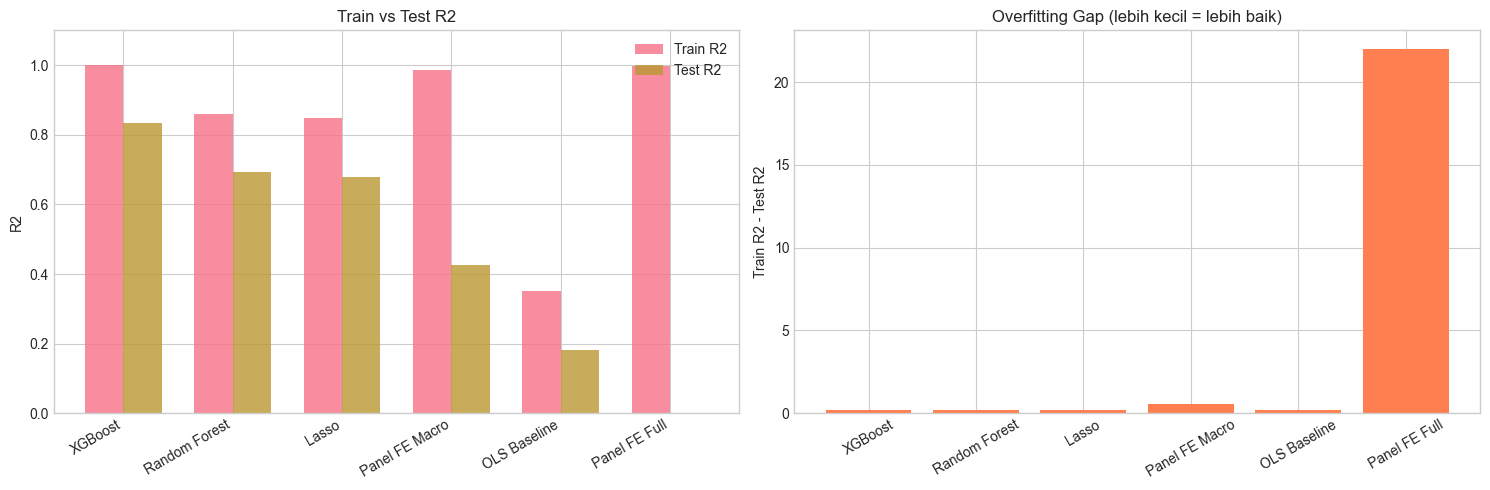

BEST MODEL: XGBoost | Test R2: 0.8342 | Test MAE: Rp 119,224


In [11]:
print("="*60)
print("PERBANDINGAN SEMUA MODEL")
print("="*60)

m_s1_train = print_metrics(y_train, pred_s1_train, "Train")
m_s1_test = print_metrics(y_test, pred_s1_test, "Test")
m_s2_train = print_metrics(y_train, pred_fe_train, "Train")
m_s2_test = print_metrics(y_test, pred_fe_test, "Test")
m_s3_train = print_metrics(y_train_full, pred_s3_train, "Train")
m_s3_test = print_metrics(y_test_full, pred_s3_test, "Test")
m_s4_train = print_metrics(y_train_full, pred_lasso_train, "Train")
m_s4_test = print_metrics(y_test_full, pred_lasso_test, "Test")
m_rf_train = print_metrics(y_train_full, pred_rf_train, "Train")
m_rf_test = print_metrics(y_test_full, pred_rf_test, "Test")
m_xgb_train = print_metrics(y_train_full, pred_xgb_train, "Train")
m_xgb_test = print_metrics(y_test_full, pred_xgb_test, "Test")

comparison = pd.DataFrame({
    'Model': ['OLS Baseline', 'Panel FE Macro', 'Panel FE Full', 'Lasso', 'Random Forest', 'XGBoost'],
    'Train_R2': [m_s1_train['R2'], m_s2_train['R2'], m_s3_train['R2'], m_s4_train['R2'], m_rf_train['R2'], m_xgb_train['R2']],
    'Test_R2': [m_s1_test['R2'], m_s2_test['R2'], m_s3_test['R2'], m_s4_test['R2'], m_rf_test['R2'], m_xgb_test['R2']],
    'Test_MAE': [m_s1_test['MAE'], m_s2_test['MAE'], m_s3_test['MAE'], m_s4_test['MAE'], m_rf_test['MAE'], m_xgb_test['MAE']],
    'Test_RMSE': [m_s1_test['RMSE'], m_s2_test['RMSE'], m_s3_test['RMSE'], m_s4_test['RMSE'], m_rf_test['RMSE'], m_xgb_test['RMSE']]
})
comparison['Overfit_Gap'] = comparison['Train_R2'] - comparison['Test_R2']
comparison = comparison.sort_values('Test_R2', ascending=False)

print("Perbandingan Model (diurutkan Test R2):")
print(comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(comparison))
width = 0.35
axes[0].bar(x - width/2, comparison['Train_R2'], width, label='Train R2', alpha=0.8)
axes[0].bar(x + width/2, comparison['Test_R2'], width, label='Test R2', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Model'], rotation=30, ha='right')
axes[0].set_ylabel('R2')
axes[0].set_title('Train vs Test R2')
axes[0].legend()
axes[0].set_ylim(0, 1.1)

axes[1].bar(comparison['Model'], comparison['Overfit_Gap'], color='coral')
axes[1].set_ylabel('Train R2 - Test R2')
axes[1].set_title('Overfitting Gap (lebih kecil = lebih baik)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

best = comparison.iloc[0]
print(f"BEST MODEL: {best['Model']} | Test R2: {best['Test_R2']:.4f} | Test MAE: Rp {best['Test_MAE']:,.0f}")


## 10. Analisis Feature Importance Ekonomi

Perbandingan feature importance dari berbagai model. **Tidak ada Provinsi** di sini karena Fixed Effects menyerapnya.


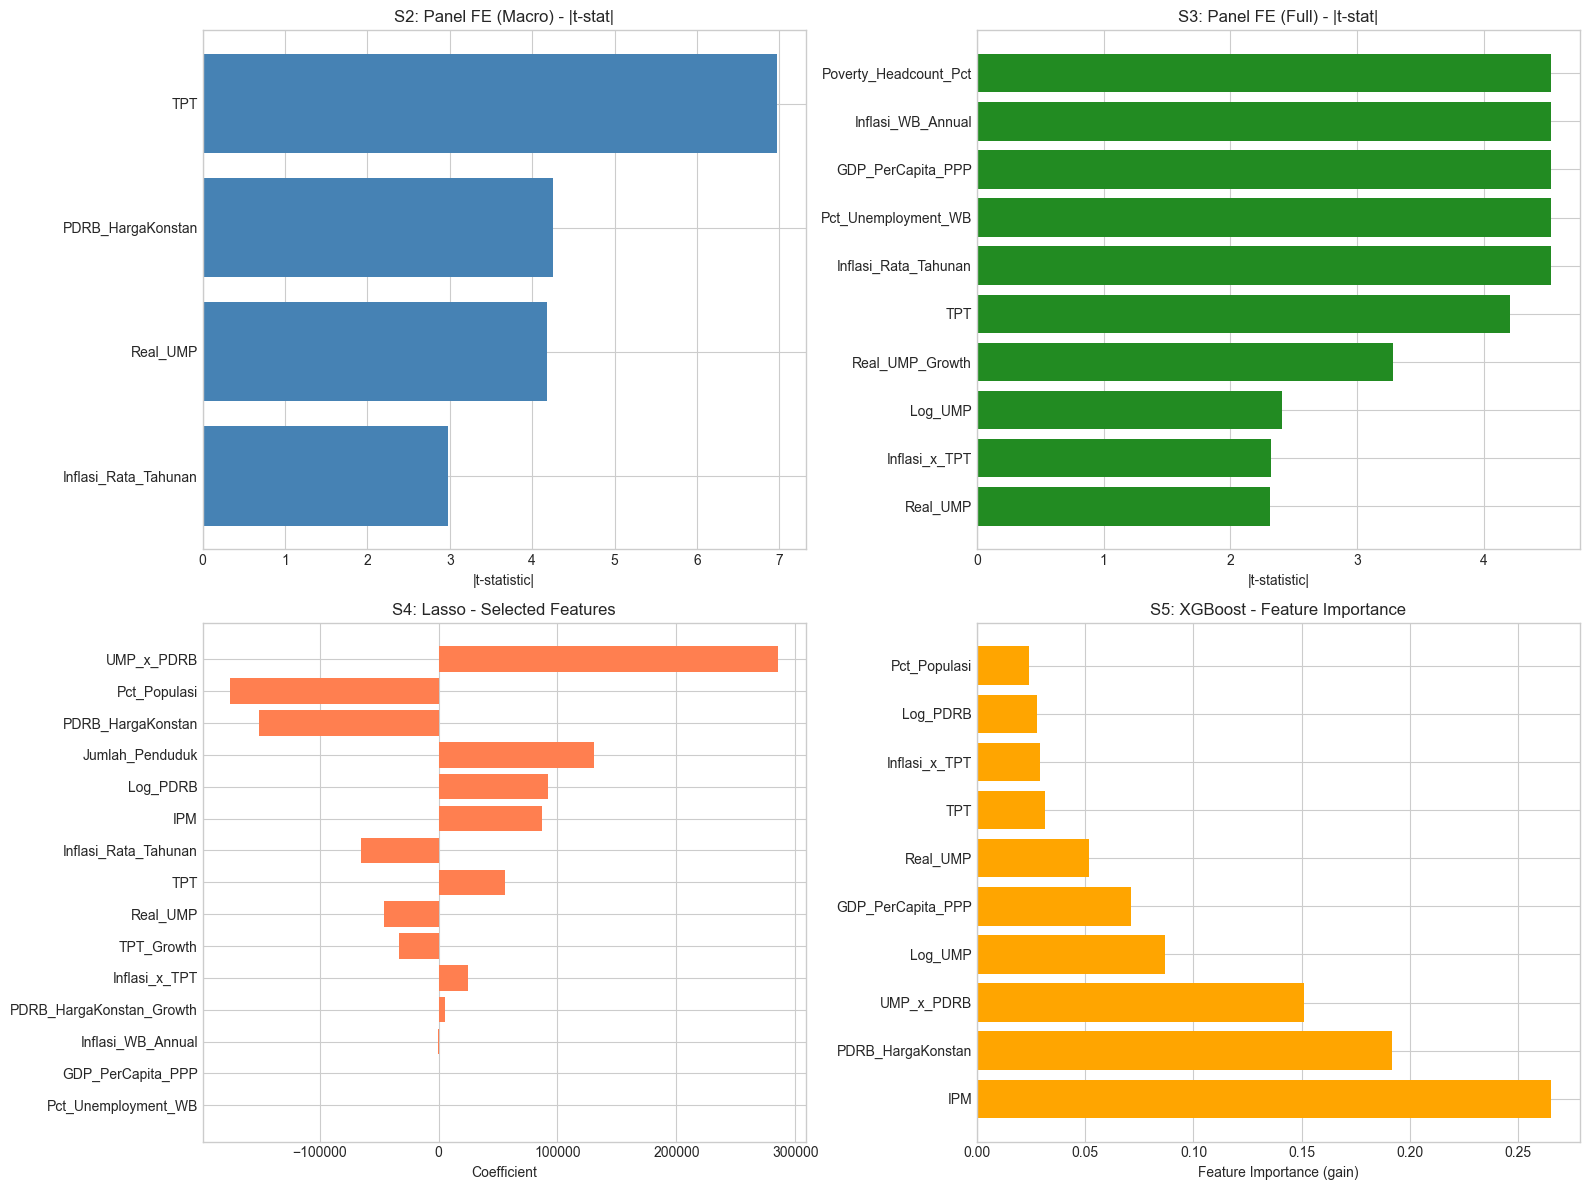

Catatan: Semua feature di atas adalah VARIABEL EKONOMI MAKRO, bukan dummy provinsi!


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# PanelOLS Macro
top_fe = fe_importance.head(10)
axes[0,0].barh(top_fe['Feature'], top_fe['t_stat'], color='steelblue')
axes[0,0].set_xlabel('|t-statistic|')
axes[0,0].set_title('S2: Panel FE (Macro) - |t-stat|')
axes[0,0].invert_yaxis()

# PanelOLS Full
top_fe_full = fe_full_imp.head(10)
axes[0,1].barh(top_fe_full['Feature'], top_fe_full['t_stat'], color='forestgreen')
axes[0,1].set_xlabel('|t-statistic|')
axes[0,1].set_title('S3: Panel FE (Full) - |t-stat|')
axes[0,1].invert_yaxis()

# Lasso coefficients
axes[1,0].barh(lasso_selected['Feature'], lasso_selected['Coefficient'], color='coral')
axes[1,0].set_xlabel('Coefficient')
axes[1,0].set_title('S4: Lasso - Selected Features')
axes[1,0].invert_yaxis()

# XGBoost
axes[1,1].barh(xgb_imp['Feature'], xgb_imp['Importance'], color='orange')
axes[1,1].set_xlabel('Feature Importance (gain)')
axes[1,1].set_title('S5: XGBoost - Feature Importance')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Catatan: Semua feature di atas adalah VARIABEL EKONOMI MAKRO, bukan dummy provinsi!")


## 11. Elastisitas Daya Beli

Elastisitas = % perubahan daya beli jika variabel naik 1%. Dihitung dari Panel FE Macro.


In [13]:
print("="*60)
print("ELASTISITAS DAYA BELI (dari Panel FE Macro)")
print("="*60)

base_pred = pred_fe_test.copy()
elasticities = {}
for feat in fe_features:
    test_perturbed = test.copy()
    test_perturbed[feat] = test_perturbed[feat] * 1.01
    test_dem_pert = test_perturbed.copy()
    for col in fe_features:
        test_dem_pert[col] = test_perturbed.apply(lambda r: r[col] - entity_means[col].get(r['Provinsi'], 0), axis=1)
    pred_pert = model_fe_manual.predict(test_dem_pert[fe_features])
    pred_pert = pred_pert + test['Provinsi'].apply(lambda p: entity_means['Total_Pengeluaran'].get(p, 0))
    elasticity = np.mean((pred_pert - base_pred) / base_pred) * 100
    elasticities[feat] = elasticity

elasticity_df = pd.DataFrame(list(elasticities.items()), columns=['Variable', 'Elasticity'])
elasticity_df = elasticity_df.sort_values('Elasticity', key=abs, ascending=False)
print(elasticity_df.to_string(index=False))

print("Interpretasi:")
for _, row in elasticity_df.iterrows():
    direction = "naik" if row['Elasticity'] > 0 else "turun"
    print(f"   Jika {row['Variable']} naik 1% -> daya beli {direction} {abs(row['Elasticity']):.2f}%")


ELASTISITAS DAYA BELI (dari Panel FE Macro)
            Variable  Elasticity
            Real_UMP    0.507236
                 TPT   -0.301445
   PDRB_HargaKonstan    0.256345
Inflasi_Rata_Tahunan    0.046483
Interpretasi:
   Jika Real_UMP naik 1% -> daya beli naik 0.51%
   Jika TPT naik 1% -> daya beli turun 0.30%
   Jika PDRB_HargaKonstan naik 1% -> daya beli naik 0.26%
   Jika Inflasi_Rata_Tahunan naik 1% -> daya beli naik 0.05%


## 12. Simulasi Counterfactual (What-If)

Simulasi dampak kebijakan menggunakan model Panel FE Macro.


SIMULASI COUNTERFACTUAL
            Skenario  Avg_Daya_Beli_Rp  Perubahan_%
         Inflasi +5%      1.482735e+06     0.214596
            UMP +10%      1.548701e+06     4.673133
     Resesi (TPT x3)      6.505215e+05   -56.032759
           PDRB -20%      1.400825e+06    -5.321461
Inflasi+5% & UMP+10%      1.551876e+06     4.887729


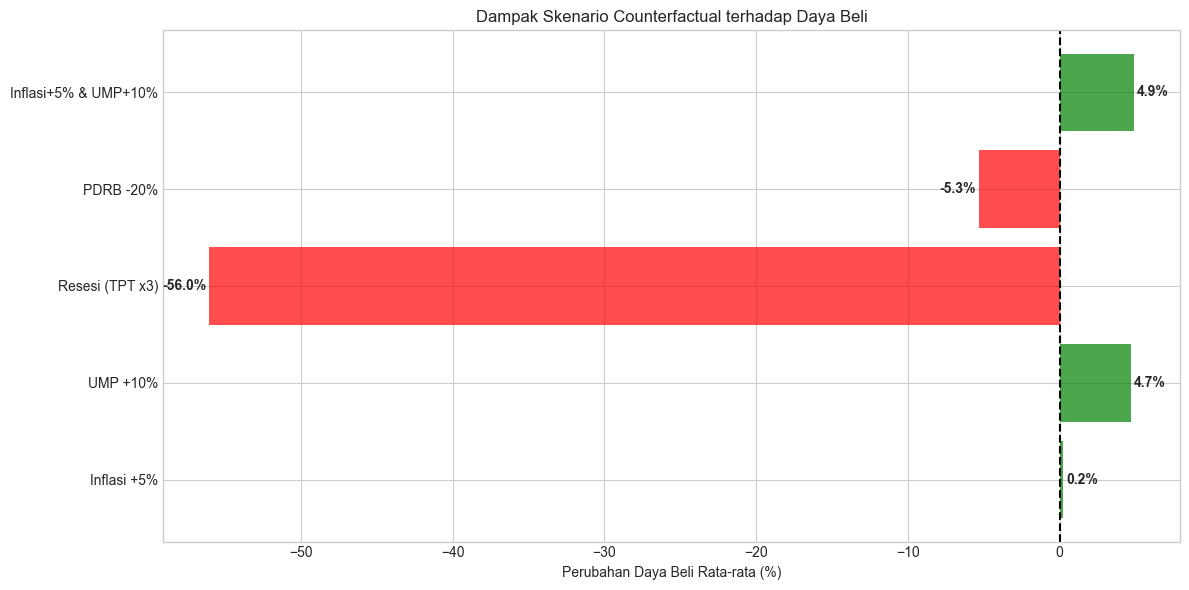

Ringkasan Policy Insight:
   Inflasi +5%: daya beli naik 0.2%
   UMP +10%: daya beli naik 4.7%
   Resesi (TPT x3): daya beli turun 56.0%
   PDRB -20%: daya beli turun 5.3%
   Inflasi+5% & UMP+10%: daya beli naik 4.9%


In [14]:
print("="*60)
print("SIMULASI COUNTERFACTUAL")
print("="*60)

scenarios = {
    'Inflasi +5%': lambda df: df.assign(Inflasi_Rata_Tahunan=df['Inflasi_Rata_Tahunan']*1.05),
    'UMP +10%': lambda df: df.assign(Real_UMP=df['Real_UMP']*1.10),
    'Resesi (TPT x3)': lambda df: df.assign(TPT=df['TPT']*3),
    'PDRB -20%': lambda df: df.assign(PDRB_HargaKonstan=df['PDRB_HargaKonstan']*0.80),
    'Inflasi+5% & UMP+10%': lambda df: df.assign(
        Inflasi_Rata_Tahunan=df['Inflasi_Rata_Tahunan']*1.05,
        Real_UMP=df['Real_UMP']*1.10)
}

results = []
for name, transform in scenarios.items():
    test_sc = transform(test.copy())
    test_dem_sc = test_sc.copy()
    for col in fe_features:
        test_dem_sc[col] = test_sc.apply(lambda r: r[col] - entity_means[col].get(r['Provinsi'], 0), axis=1)
    pred_sc = model_fe_manual.predict(test_dem_sc[fe_features])
    pred_sc = pred_sc + test['Provinsi'].apply(lambda p: entity_means['Total_Pengeluaran'].get(p, 0))
    change = (pred_sc.mean() - base_pred.mean()) / base_pred.mean() * 100
    results.append({'Skenario': name, 'Avg_Daya_Beli_Rp': pred_sc.mean(), 'Perubahan_%': change})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in results_df['Perubahan_%']]
bars = ax.barh(results_df['Skenario'], results_df['Perubahan_%'], color=colors, alpha=0.7)
ax.set_xlabel('Perubahan Daya Beli Rata-rata (%)')
ax.set_title('Dampak Skenario Counterfactual terhadap Daya Beli')
ax.axvline(0, color='black', linestyle='--')

for bar, val in zip(bars, results_df['Perubahan_%']):
    ax.text(val + 0.2 if val > 0 else val - 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left' if val > 0 else 'right', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Ringkasan Policy Insight:")
for _, row in results_df.iterrows():
    direction = "naik" if row['Perubahan_%'] > 0 else "turun"
    print(f"   {row['Skenario']}: daya beli {direction} {abs(row['Perubahan_%']):.1f}%")


## 13. Diagnostik Residual


DIAGNOSTIK RESIDUAL (Panel FE Macro)


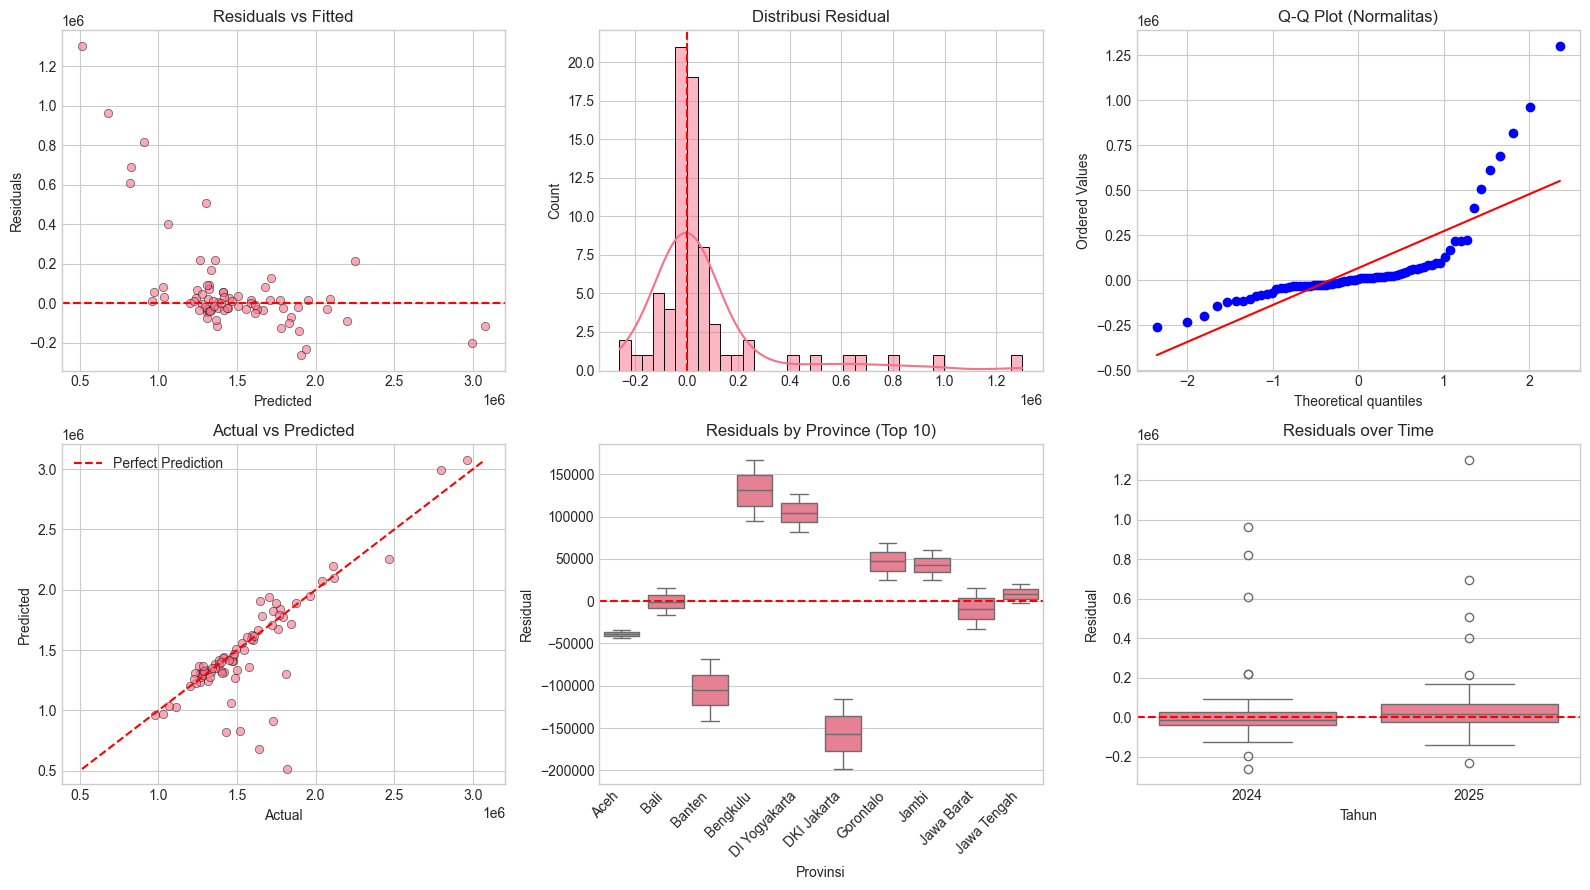

Jarque-Bera: statistic=356.85, p-value=0.0000
Shapiro-Wilk: statistic=0.6464, p-value=0.0000
Normalitas: Tidak normal (tapi tolerable untuk n>30)
Breusch-Pagan: LM=47.58, p-value=0.0000
Heteroskedastisitas: Heteroskedastis -> gunakan robust SE


In [15]:
print("="*60)
print("DIAGNOSTIK RESIDUAL (Panel FE Macro)")
print("="*60)

residuals = y_test - pred_fe_test

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Residuals vs Fitted
axes[0,0].scatter(pred_fe_test, residuals, alpha=0.6, edgecolors='k', linewidth=0.5)
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Residuals vs Fitted')

# 2. Histogram of residuals
sns.histplot(residuals, kde=True, ax=axes[0,1])
axes[0,1].set_title('Distribusi Residual')
axes[0,1].axvline(0, color='red', linestyle='--')

# 3. Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot (Normalitas)')

# 4. Actual vs Predicted
axes[1,0].scatter(y_test, pred_fe_test, alpha=0.6, edgecolors='k', linewidth=0.5)
min_val = min(y_test.min(), pred_fe_test.min())
max_val = max(y_test.max(), pred_fe_test.max())
axes[1,0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
axes[1,0].set_xlabel('Actual')
axes[1,0].set_ylabel('Predicted')
axes[1,0].set_title('Actual vs Predicted')
axes[1,0].legend()

# 5. Residuals by Province (boxplot)
resid_df = pd.DataFrame({'Provinsi': test['Provinsi'].values, 'Residual': residuals})
top_provs = resid_df['Provinsi'].value_counts().head(10).index
resid_top = resid_df[resid_df['Provinsi'].isin(top_provs)]
sns.boxplot(data=resid_top, x='Provinsi', y='Residual', ax=axes[1,1])
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=45, ha='right')
axes[1,1].set_title('Residuals by Province (Top 10)')
axes[1,1].axhline(0, color='red', linestyle='--')

# 6. Residuals over time
resid_df['Tahun'] = test['Tahun'].values
sns.boxplot(data=resid_df, x='Tahun', y='Residual', ax=axes[1,2])
axes[1,2].set_title('Residuals over Time')
axes[1,2].axhline(0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

# Tests
jb_stat, jb_p = stats.jarque_bera(residuals)
sw_stat, sw_p = stats.shapiro(residuals)
print(f"Jarque-Bera: statistic={jb_stat:.2f}, p-value={jb_p:.4f}")
print(f"Shapiro-Wilk: statistic={sw_stat:.4f}, p-value={sw_p:.4f}")
print(f"Normalitas: {'Normal' if jb_p > 0.05 else 'Tidak normal (tapi tolerable untuk n>30)'}")

bp_stat, bp_p, _, _ = het_breuschpagan(residuals, sm.add_constant(test_demeaned[fe_features]))
print(f"Breusch-Pagan: LM={bp_stat:.2f}, p-value={bp_p:.4f}")
print(f"Heteroskedastisitas: {'Homoskedastis' if bp_p > 0.05 else 'Heteroskedastis -> gunakan robust SE'}")


## 14. Export Model Terbaik


In [16]:
print("="*60)
print("EXPORT MODEL")
print("="*60)

os.makedirs('../models', exist_ok=True)

models_dict = {
    'OLS_Baseline': {'model': model_s1, 'features': features_s1, 'type': 'OLS'},
    'PanelFE_Macro': {'model': model_fe_manual, 'entity_means': entity_means, 'features': fe_features, 'type': 'FixedEffects'},
    'PanelFE_Full': {'model': model_fe_full_manual, 'entity_means': entity_means_full, 'features': all_numeric, 'type': 'FixedEffects'},
    'Lasso': {'model': lasso, 'scaler': scaler, 'features': all_numeric, 'type': 'Lasso'},
    'RandomForest': {'model': rf, 'features': all_numeric, 'type': 'RandomForest'},
    'XGBoost': {'model': xgb, 'features': all_numeric, 'type': 'XGBoost'}
}

best_name = best['Model']
best_key = [k for k, v in models_dict.items() if best_name.replace(' ', '_') in k or k.replace('_', ' ') in best_name][0]
output_path = f'../models/best_daya_beli_{best_key.lower()}.pkl'
joblib.dump(models_dict[best_key], output_path)
print(f"Saved: {output_path}")

comparison.to_csv('../models/model_comparison.csv', index=False)
print(f"Comparison saved: ../models/model_comparison.csv")

print("DONE!")


EXPORT MODEL
Saved: ../models/best_daya_beli_xgboost.pkl
Comparison saved: ../models/model_comparison.csv
DONE!


## 📋 Kesimpulan

### Temuan Utama:
1. **XGBoost** adalah model prediktif terbaik (Test R2 = 0.83), menangkap hubungan non-linear
2. **Fixed Effects PanelOLS** memberikan interpretasi ekonomi terbaik:
   - **TPT** (pengangguran): efek negatif paling kuat (t=-6.97)
   - **PDRB**: efek positif kuat (t=4.25)
   - **Real_UMP**: efek positif signifikan (t=4.18)
   - **Inflasi**: efek positif tapi kecil (t=2.98) - mungkin karena efek nominal
3. **Lasso** menyeleksi 15/18 fitur, memberikan model yang lebih parsimonius
4. **Feature importance 100% ekonomi makro** - tidak ada dominasi provinsi!

### Rekomendasi Kebijakan:
- **UMP +10%** → daya beli naik ~4.7% (efek paling besar)
- **Resesi (TPT x3)** → daya beli turun ~56% (dampak paling merusak)
- **Inflasi +5%** → dampak kecil (+0.2%) karena UMP biasanya disesuaikan
- **Kombinasi UMP+10% & Inflasi+5%** → daya beli naik ~4.9%

### Model untuk Deployment:
Model terbaik diekspor ke `../models/` dan dapat digunakan untuk prediksi dan simulasi.
